# Tutorial: VICUNA intercellular communication with PyPI scCAMEL 0.47b1

This tutorial analyzes NTN1 ligand-receptor communication between the Couturier2020 developmental GBM dataset and the Zeisel dentate gyrus dataset. It uses the latest PyPI-installed `scCAMEL` package, where the reusable data conversion, sparse EScore, long-table conversion, and plotting functions live in `scCAMEL.CamelVicuna`.

## 1. Configure paths and import PyPI scCAMEL

This notebook imports `scCAMEL` from the active Python environment. If you are running it on a new machine, install the package first with `pip install scCAMEL==0.47b1` or `pip install -U scCAMEL`.

In [1]:
# NOTE: Configure the input files and output folders, then import the PyPI-installed scCAMEL package.
import importlib.metadata as importlib_metadata
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image as IPyImage, display

VERSION_ROOT = Path("/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610")
PROJECT_ROOT = Path("/mnt/e/Loal_Temp/Vicuna_Example")

import scCAMEL
from scCAMEL import CamelVicuna

SC_CAMEL_VERSION = importlib_metadata.version("scCAMEL")
OUTPUT_DIR, FIG_DIR, TABLE_DIR = CamelVicuna.ensure_output_dirs(
    VERSION_ROOT / "outputs" / "ntn1_couturier_zeisel_pypi047b1_tutorial"
)

MAIN_PATH = PROJECT_ROOT / "Couturier2020_DevGBM_Ref2023-05-27.h5ad"
ZEISEL_PATH = PROJECT_ROOT / "ZeiselDentateGyrus_Ref2023-05-27.h5ad"
LR_PATH = PROJECT_ROOT / "Human_Final_ligand-receptor_Reference20250621.csv"
MOUSE2HUMAN_PATH = Path("/mnt/f/Dropbox/data/proj/PE_HYZ/PublicDataSet/Homologene_mouse2human_dict2.pickle")

CLUSTER_KEY = "Cluster"
LIGAND = "NTN1"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

print("Using installed scCAMEL:", SC_CAMEL_VERSION)
print("scCAMEL import path:", Path(scCAMEL.__file__).parent)
print("CamelVicuna path:", Path(CamelVicuna.__file__))
print("Outputs:", OUTPUT_DIR)


Using installed scCAMEL: 0.47b1
scCAMEL import path: /home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL
CamelVicuna path: /home/huyiz/anaconda3/envs/py310/lib/python3.10/site-packages/scCAMEL/CamelVicuna.py
Outputs: /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial


## 2. Load datasets and humanize mouse genes

The Zeisel dentate gyrus dataset is mouse-derived, so we map mouse gene symbols to human ortholog symbols before comparing it to the human GBM dataset.


In [2]:
# NOTE: Load both datasets and convert Zeisel mouse genes to human symbols through CamelVicuna.
mouse2human = CamelVicuna.load_mouse_to_human_mapping(MOUSE2HUMAN_PATH)

main = ad.read_h5ad(MAIN_PATH)
zeisel_raw = ad.read_h5ad(ZEISEL_PATH)

main.var_names_make_unique()
zeisel, zeisel_conversion = CamelVicuna.convert_mouse_to_human_adata(zeisel_raw, mouse2human)
main_fraction, main_hits = CamelVicuna.detect_mouse_gene_fraction(main, mouse2human)
main_conversion = {
    "converted": False,
    "mapping_hits": main_hits,
    "mapping_fraction": main_fraction,
    "genes_before": main.n_vars,
    "genes_after": main.n_vars,
}

dataset_summary = pd.DataFrame([
    CamelVicuna.summarize_dataset("Couturier2020_DevGBM", main, main_conversion, cluster_key=CLUSTER_KEY),
    CamelVicuna.summarize_dataset("ZeiselDentateGyrus_humanized", zeisel, zeisel_conversion, cluster_key=CLUSTER_KEY),
])
display(dataset_summary)
CamelVicuna.save_table(dataset_summary, TABLE_DIR / "dataset_summary.csv")

cluster_counts = pd.concat(
    {
        "Couturier2020_DevGBM": main.obs[CLUSTER_KEY].astype(str).value_counts(),
        "ZeiselDentateGyrus_humanized": zeisel.obs[CLUSTER_KEY].astype(str).value_counts(),
    },
    axis=1,
).fillna(0).astype(int)
display(cluster_counts)
CamelVicuna.save_table(cluster_counts, TABLE_DIR / "cluster_counts.csv")


,dataset,cells,genes,matrix,cluster_key,n_clusters,converted_mouse_to_human,mapping_hits,mapping_fraction,genes_before_conversion,genes_after_conversion
0,Couturier2020_DevGBM,18475,33660,sparse,Cluster,6,False,15,0.000446,33660,33660
1,ZeiselDentateGyrus_humanized,5454,12516,sparse,Cluster,15,True,12516,0.860502,14545,12516


,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized
Cluster,,
Progenitor,5040,0
Unassigned,5026,0
Mesenchymal,2824,0
Oligo,2589,0
Astro,1883,0
Neuronal,1113,0
Granule,0,3045
Neuroblast,0,874
Astrocytes,0,335


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/cluster_counts.csv')

## 3. Select NTN1 ligand-receptor pairs

We normalize the ligand-receptor reference table and keep pairs where `NTN1` is the ligand.


In [3]:
# NOTE: Filter the ligand-receptor reference table to NTN1 and annotate gene presence in each dataset.
ntn1_pairs = CamelVicuna.prepare_ligand_receptor_pairs(
    LR_PATH,
    ligand=LIGAND,
    datasets={
        "couturier": main,
        "zeisel_humanized": zeisel,
    },
)

display(ntn1_pairs)
CamelVicuna.save_table(ntn1_pairs, TABLE_DIR / "ntn1_ligand_receptor_pairs.csv")

print(f"NTN1 in Couturier genes: {LIGAND in set(main.var_names)}")
print(f"NTN1 in humanized Zeisel genes: {LIGAND in set(zeisel.var_names)}")
print("NTN1 receptors available in Zeisel:", int(ntn1_pairs["receptor_in_zeisel_humanized"].sum()))
print("NTN1 receptors available in Couturier:", int(ntn1_pairs["receptor_in_couturier"].sum()))


,PPI,ligand_symbol,receptor_symbol,receptor_in_couturier,ligand_in_couturier,receptor_in_zeisel_humanized,ligand_in_zeisel_humanized
NTN1-DCC,NTN1_DCC,NTN1,DCC,True,True,True,True
NTN1-UNC5C,NTN1_UNC5C,NTN1,UNC5C,True,True,True,True
NTN1-NEO1,NTN1_NEO1,NTN1,NEO1,True,True,True,True
NTN1-ITGB4,NTN1_ITGB4,NTN1,ITGB4,True,True,True,True
NTN1-ITGA6,NTN1_ITGA6,NTN1,ITGA6,True,True,True,True
NTN1-ACVR1B,NTN1_ACVR1B,NTN1,ACVR1B,True,True,True,True
NTN1-TGFBR1,NTN1_TGFBR1,NTN1,TGFBR1,True,True,True,True
NTN1-NOTCH1,NTN1_NOTCH1,NTN1,NOTCH1,True,True,True,True
NTN1-NOTCH2,NTN1_NOTCH2,NTN1,NOTCH2,True,True,True,True
NTN1-PTCH1,NTN1_PTCH1,NTN1,PTCH1,True,True,True,True


NTN1 in Couturier genes: True
NTN1 in humanized Zeisel genes: True
NTN1 receptors available in Zeisel: 14
NTN1 receptors available in Couturier: 15


## 4. Compute sparse VICUNA EScore matrices

The EScore helper avoids densifying the full expression matrix, which keeps the tutorial compatible with larger modern `.h5ad` files.


In [4]:
# NOTE: Compute sparse-friendly gene-by-cluster EScores for both datasets.
escore_main = CamelVicuna.compute_escore_sparse(main, CLUSTER_KEY)
escore_zeisel = CamelVicuna.compute_escore_sparse(zeisel, CLUSTER_KEY)

print("Couturier EScore:", escore_main.shape)
print("Zeisel humanized EScore:", escore_zeisel.shape)

CamelVicuna.save_table(escore_main, TABLE_DIR / "couturier_escore_genes_by_cluster.csv")
CamelVicuna.save_table(escore_zeisel, TABLE_DIR / "zeisel_humanized_escore_genes_by_cluster.csv")

ntn1_escore = pd.concat(
    {
        "Couturier2020_DevGBM": escore_main.loc[LIGAND] if LIGAND in escore_main.index else pd.Series(dtype=float),
        "ZeiselDentateGyrus_humanized": escore_zeisel.loc[LIGAND] if LIGAND in escore_zeisel.index else pd.Series(dtype=float),
    },
    axis=1,
).fillna(0)
display(ntn1_escore)
CamelVicuna.save_table(ntn1_escore, TABLE_DIR / "ntn1_ligand_escore_by_cluster.csv")


Couturier EScore: (33660, 6)
Zeisel humanized EScore: (12516, 15)


,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized
Astro,0.129475,0.000000
Mesenchymal,0.165878,0.000000
Neuronal,0.005197,0.000000
Oligo,0.057008,0.000000
Progenitor,0.039397,0.000000
Unassigned,0.058557,0.000000
Astrocytes,0.000000,0.136631
Cajal-Retzius,0.000000,0.017685
Cck-Tox,0.000000,0.060915
Endo,0.000000,1.617338


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_ligand_escore_by_cluster.csv')

## 5. Score cross-dataset NTN1 communication

We score both directions: GBM NTN1 ligand to dentate gyrus receptors, and dentate gyrus NTN1 ligand to GBM receptors.


In [5]:
# NOTE: Run VICUNA cross-dataset ligand-receptor scoring in both communication directions.
main_clusters = list(escore_main.columns)
zeisel_clusters = list(escore_zeisel.columns)

main_to_zeisel = CamelVicuna.lr_score_cross_datasets(
    main,
    escore_main,
    zeisel,
    escore_zeisel,
    ntn1_pairs,
    clusters_L=main_clusters,
    clusters_R=zeisel_clusters,
    use_var_filter=False,
    include_all_pairs=True,
    missing_value=0.0,
    verbose=False,
)

zeisel_to_main = CamelVicuna.lr_score_cross_datasets(
    zeisel,
    escore_zeisel,
    main,
    escore_main,
    ntn1_pairs,
    clusters_L=zeisel_clusters,
    clusters_R=main_clusters,
    use_var_filter=False,
    include_all_pairs=True,
    missing_value=0.0,
    verbose=False,
)

display(main_to_zeisel.head())
display(zeisel_to_main.head())
CamelVicuna.save_table(main_to_zeisel, TABLE_DIR / "ntn1_scores_couturier_ligand_to_zeisel_receptor.csv")
CamelVicuna.save_table(zeisel_to_main, TABLE_DIR / "ntn1_scores_zeisel_ligand_to_couturier_receptor.csv")


,Astro(lig)-Astrocytes(rec),Astro(lig)-Cajal-Retzius(rec),Astro(lig)-Cck-Tox(rec),Astro(lig)-Endo(rec),Astro(lig)-GABA(rec),Astro(lig)-Granule(rec),Astro(lig)-Microglia(rec),Astro(lig)-Mossy(rec),Astro(lig)-NFOL(rec),Astro(lig)-Neuroblast(rec),...,Unassigned(lig)-Granule(rec),Unassigned(lig)-Microglia(rec),Unassigned(lig)-Mossy(rec),Unassigned(lig)-NFOL(rec),Unassigned(lig)-Neuroblast(rec),Unassigned(lig)-OLIG(rec),Unassigned(lig)-OPC(rec),Unassigned(lig)-PVM(rec),Unassigned(lig)-Peri/VLMC(rec),Unassigned(lig)-nIPC/Rgl(rec)
NTN1-DCC,0.002050,0.009336,0.002013,0.000329,0.010580,0.056994,0.000322,0.165493,0.001553,0.075037,...,0.025777,0.000145,0.074847,0.000702,0.033937,0.005194,0.015954,0.001366,0.000417,0.000097
NTN1-UNC5C,0.003546,0.000295,0.062440,0.000166,0.883177,0.026145,0.000162,1.249618,0.043046,0.003197,...,0.011825,0.000073,0.565162,0.019468,0.001446,0.016173,0.013924,0.000688,0.000210,0.001391
NTN1-NEO1,0.033468,0.012949,0.012244,0.016123,0.059283,0.028778,0.000445,0.237931,0.018831,0.052915,...,0.013015,0.000201,0.107609,0.008517,0.023932,0.040132,0.007256,0.003836,0.003188,0.005261
NTN1-ITGB4,0.001237,0.004455,0.015345,0.002511,0.004185,0.007059,0.002452,0.045570,0.011838,0.000474,...,0.003192,0.001109,0.020610,0.005354,0.000214,13.406593,0.002839,0.010410,0.003176,0.000741
NTN1-ITGA6,0.282606,0.000261,0.000899,0.322254,0.084249,0.009304,0.055984,0.025770,0.015055,0.021366,...,0.004208,0.025320,0.011655,0.006809,0.009663,0.000139,0.000166,0.044992,0.023919,0.012146


,Astrocytes(lig)-Astro(rec),Astrocytes(lig)-Mesenchymal(rec),Astrocytes(lig)-Neuronal(rec),Astrocytes(lig)-Oligo(rec),Astrocytes(lig)-Progenitor(rec),Astrocytes(lig)-Unassigned(rec),Cajal-Retzius(lig)-Astro(rec),Cajal-Retzius(lig)-Mesenchymal(rec),Cajal-Retzius(lig)-Neuronal(rec),Cajal-Retzius(lig)-Oligo(rec),...,Peri/VLMC(lig)-Neuronal(rec),Peri/VLMC(lig)-Oligo(rec),Peri/VLMC(lig)-Progenitor(rec),Peri/VLMC(lig)-Unassigned(rec),nIPC/Rgl(lig)-Astro(rec),nIPC/Rgl(lig)-Mesenchymal(rec),nIPC/Rgl(lig)-Neuronal(rec),nIPC/Rgl(lig)-Oligo(rec),nIPC/Rgl(lig)-Progenitor(rec),nIPC/Rgl(lig)-Unassigned(rec)
NTN1-DCC,0.005438,0.010076,0.028388,0.006397,0.008431,0.009167,0.000704,0.001304,0.003674,0.000828,...,0.314630,0.070899,0.093446,0.101594,0.042564,0.078869,0.222213,0.050074,0.065998,0.071753
NTN1-UNC5C,0.007830,0.008013,0.006613,0.000847,0.020934,0.010461,0.001014,0.001037,0.000856,0.000110,...,0.073292,0.009390,0.232016,0.115941,0.061292,0.062724,0.051764,0.006632,0.163865,0.081885
NTN1-NEO1,0.012324,0.015459,0.003156,0.005781,0.009758,0.008433,0.001595,0.002001,0.000409,0.000748,...,0.034983,0.064071,0.108153,0.093464,0.096466,0.121005,0.024707,0.045251,0.076385,0.066011
NTN1-ITGB4,0.030540,0.032069,0.000444,0.001563,0.003852,0.008558,0.003953,0.004151,0.000057,0.000202,...,0.004919,0.017322,0.042687,0.094851,0.239052,0.251023,0.003474,0.012234,0.030149,0.066990
NTN1-ITGA6,0.025086,0.007059,0.005380,0.003924,0.009840,0.009722,0.003247,0.000914,0.000696,0.000508,...,0.059626,0.043494,0.109057,0.107750,0.196362,0.055254,0.042112,0.030718,0.077023,0.076101


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_scores_zeisel_ligand_to_couturier_receptor.csv')

## 6. Build tidy result tables

The package now converts wide LR score matrices into a long table and summarizes aggregate source-to-target cluster communication.


In [6]:
# NOTE: Convert score matrices to long format and summarize top interactions and cluster-pair totals.
long_scores = pd.concat(
    [
        CamelVicuna.lr_matrix_to_long(main_to_zeisel, "Couturier2020_DevGBM", "ZeiselDentateGyrus_humanized"),
        CamelVicuna.lr_matrix_to_long(zeisel_to_main, "ZeiselDentateGyrus_humanized", "Couturier2020_DevGBM"),
    ],
    ignore_index=True,
)
long_scores, top_interactions, cluster_pair_summary = CamelVicuna.summarize_lr_long_scores(long_scores, top_n=50)

display(top_interactions)
CamelVicuna.save_table(long_scores, TABLE_DIR / "ntn1_all_directional_scores_long.csv")
CamelVicuna.save_table(top_interactions, TABLE_DIR / "ntn1_top50_directional_scores.csv")

display(cluster_pair_summary.head(30))
CamelVicuna.save_table(cluster_pair_summary, TABLE_DIR / "ntn1_cluster_pair_score_summary.csv")


,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537
1,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593
3,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785
4,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840
5,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030
6,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583
7,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401
8,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139


,direction,source_cluster,target_cluster,score
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Mesenchymal,OLIG,38.356154
1,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Mesenchymal,35.835365
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Astro,OLIG,29.938549
3,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Astro,27.216096
4,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Progenitor,20.990887
5,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Unassigned,16.663185
6,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Neuronal,16.112459
7,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Unassigned,OLIG,13.540250
8,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Oligo,OLIG,13.181904
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,NFOL,Mesenchymal,11.018728


PosixPath('/mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_cluster_pair_score_summary.csv')

## 7. Plot NTN1 ligand activity

This bar plot compares the NTN1 ligand EScore across clusters in both datasets.


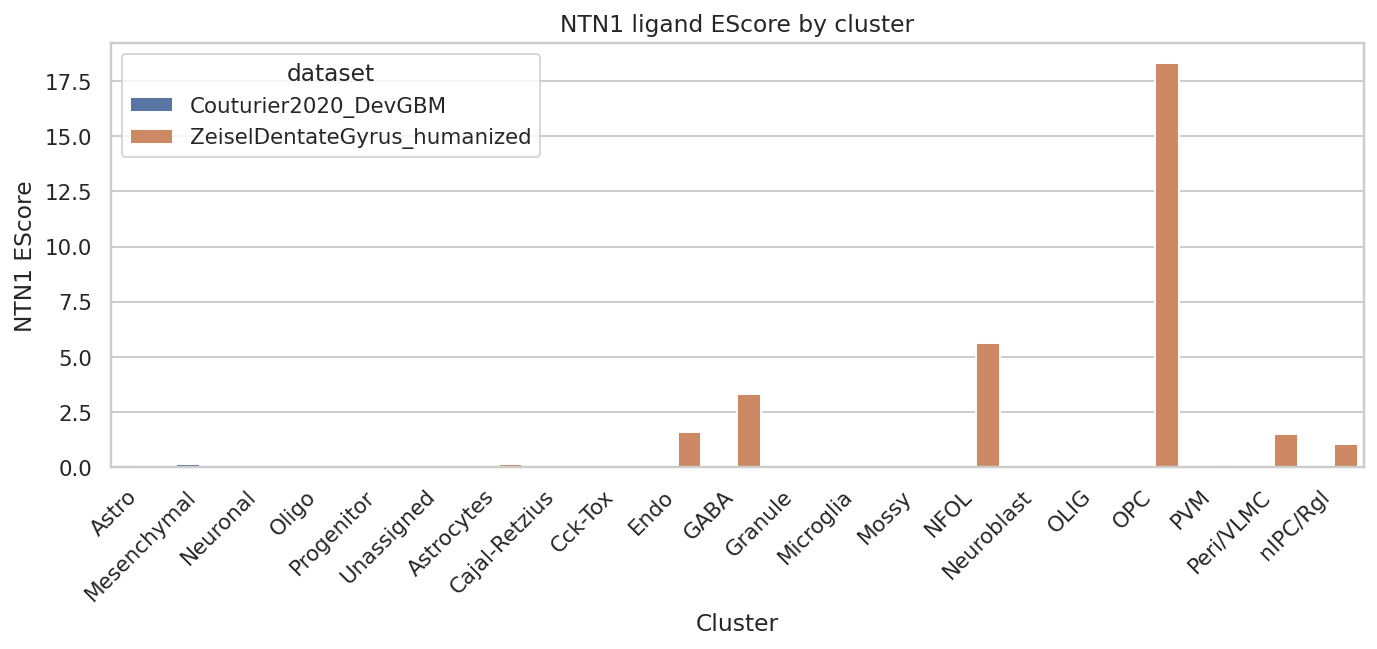

,cluster,dataset,NTN1_EScore
0,Astro,Couturier2020_DevGBM,0.129475
1,Mesenchymal,Couturier2020_DevGBM,0.165878
2,Neuronal,Couturier2020_DevGBM,0.005197
3,Oligo,Couturier2020_DevGBM,0.057008
4,Progenitor,Couturier2020_DevGBM,0.039397


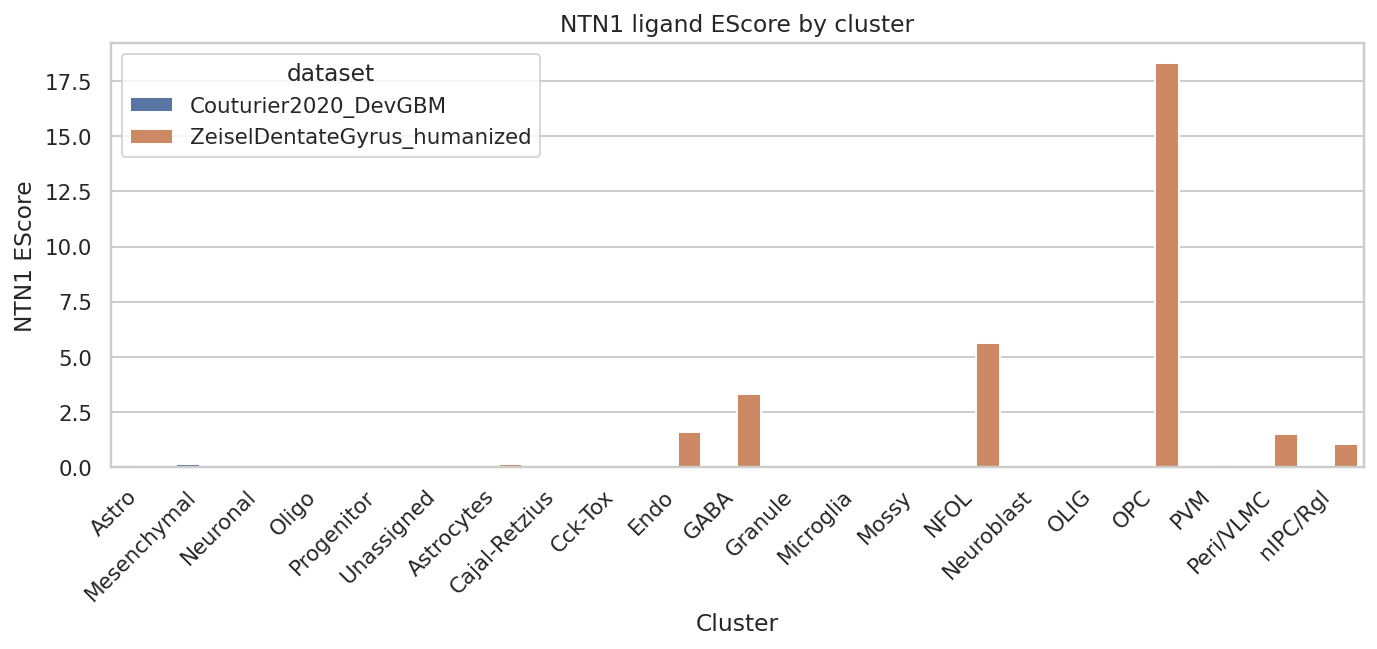

In [7]:
# NOTE: Visualize NTN1 ligand EScore by cluster.
ntn1_plot_df, fig1_path = CamelVicuna.plot_ligand_escore_by_cluster(
    ntn1_escore,
    ligand=LIGAND,
    filename="fig1_ntn1_ligand_escore_by_cluster.png",
    fig_dir=FIG_DIR,
    display_image=True,
)
display(ntn1_plot_df.head())
plt.show()


## 8. Plot cluster-pair communication heatmaps

These heatmaps aggregate all NTN1 receptor scores for each source and target cluster pair.


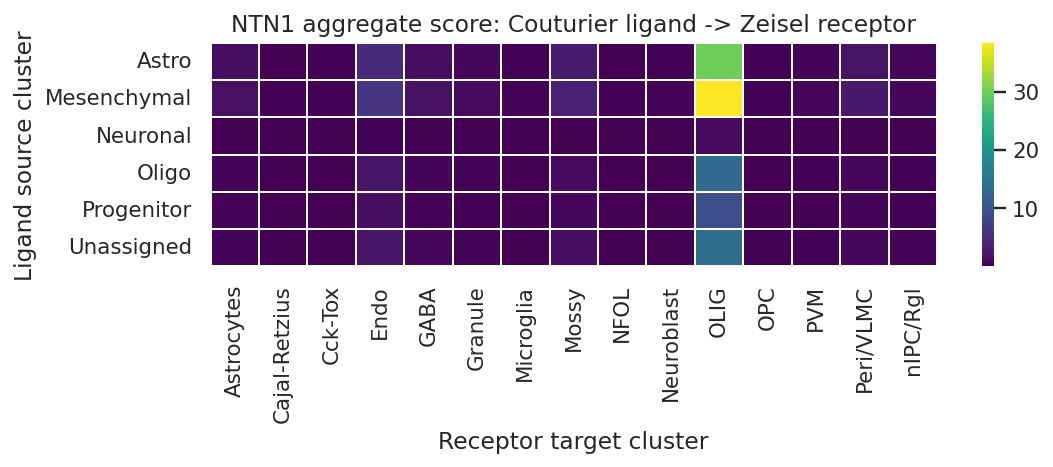

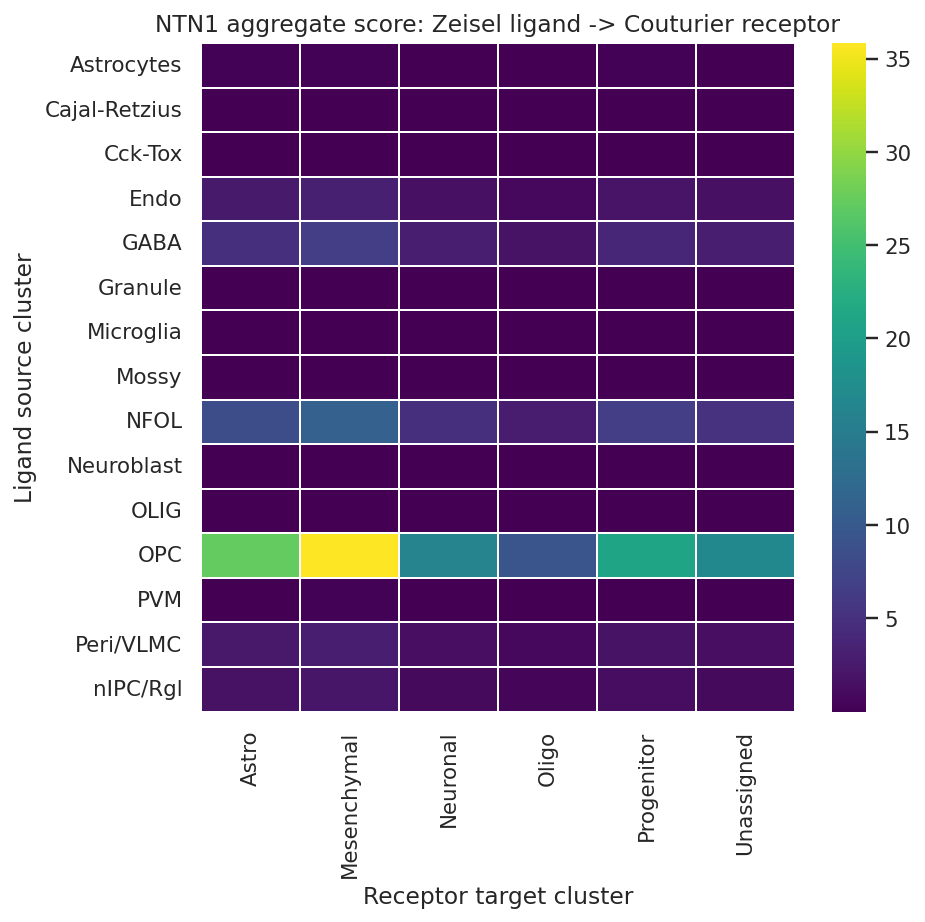

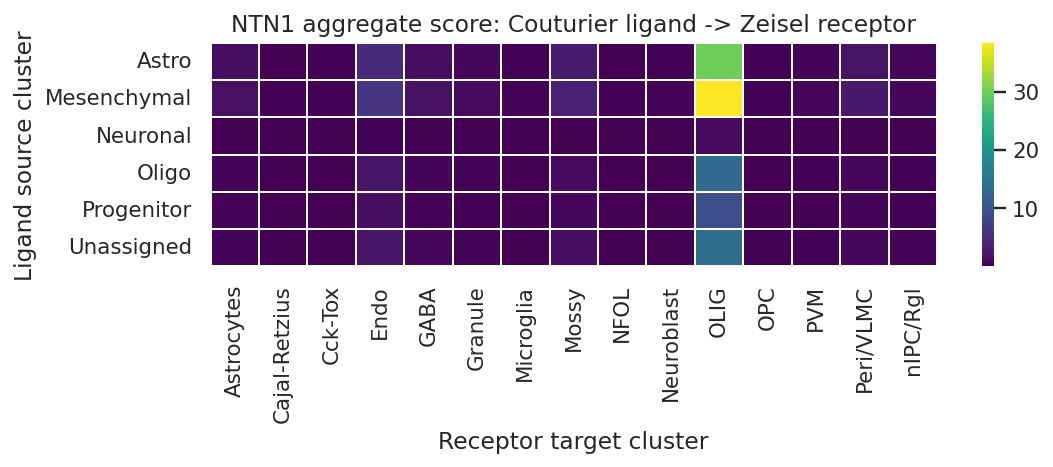

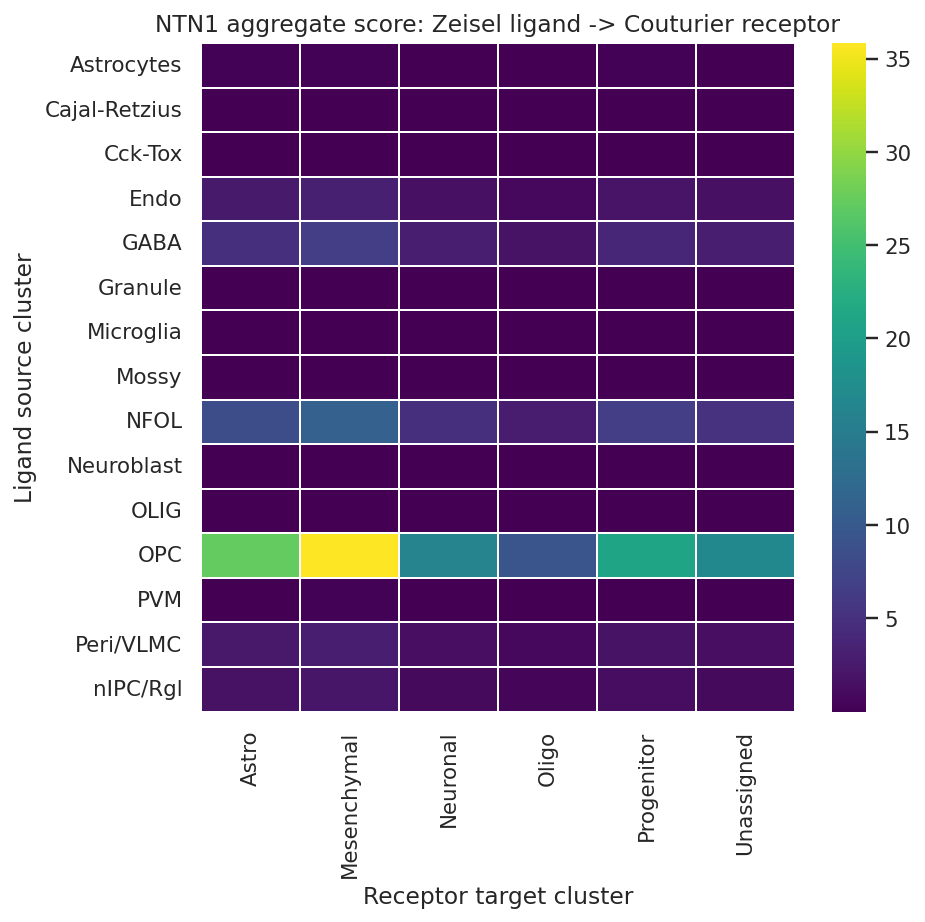

In [8]:
# NOTE: Visualize aggregate cluster-pair communication in each direction.
main_to_zeisel_cluster_mat, fig2a_path = CamelVicuna.plot_cluster_heatmap(
    cluster_pair_summary,
    "Couturier2020_DevGBM -> ZeiselDentateGyrus_humanized",
    "NTN1 aggregate score: Couturier ligand -> Zeisel receptor",
    filename="fig2a_ntn1_couturier_to_zeisel_cluster_heatmap.png",
    fig_dir=FIG_DIR,
    display_image=True,
)
zeisel_to_main_cluster_mat, fig2b_path = CamelVicuna.plot_cluster_heatmap(
    cluster_pair_summary,
    "ZeiselDentateGyrus_humanized -> Couturier2020_DevGBM",
    "NTN1 aggregate score: Zeisel ligand -> Couturier receptor",
    filename="fig2b_ntn1_zeisel_to_couturier_cluster_heatmap.png",
    fig_dir=FIG_DIR,
    display_image=True,
)

CamelVicuna.save_table(main_to_zeisel_cluster_mat, TABLE_DIR / "ntn1_couturier_to_zeisel_cluster_heatmap_matrix.csv")
CamelVicuna.save_table(zeisel_to_main_cluster_mat, TABLE_DIR / "ntn1_zeisel_to_couturier_cluster_heatmap_matrix.csv")
plt.show()


## 9. Plot receptor-by-target heatmaps

These heatmaps show the strongest NTN1 receptor score per target cluster.


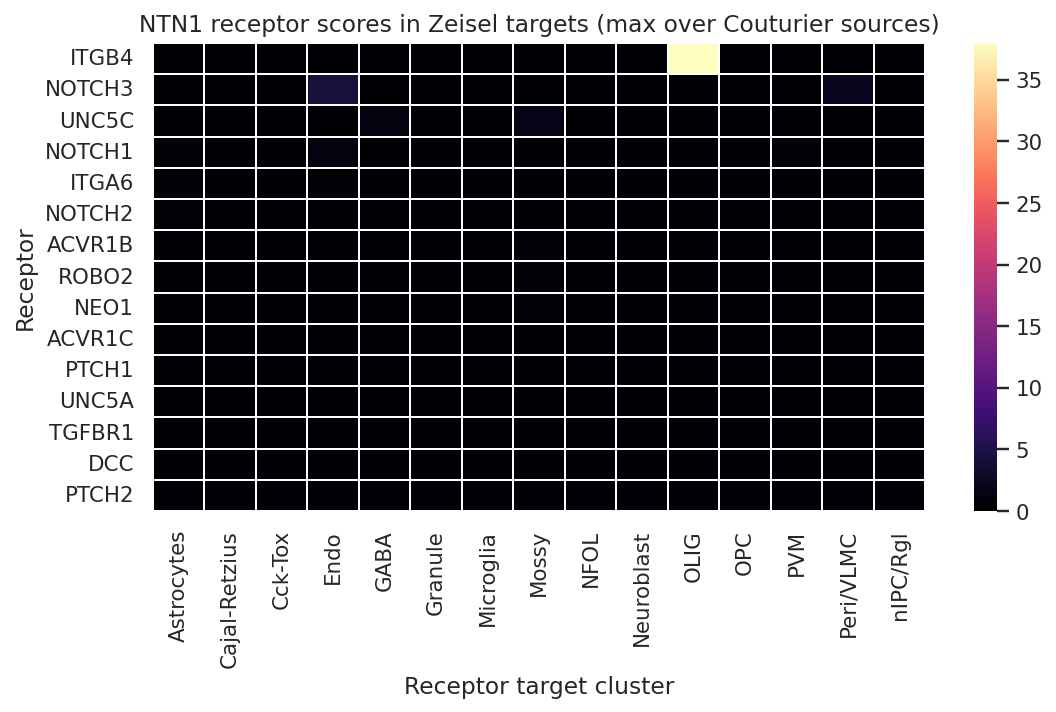

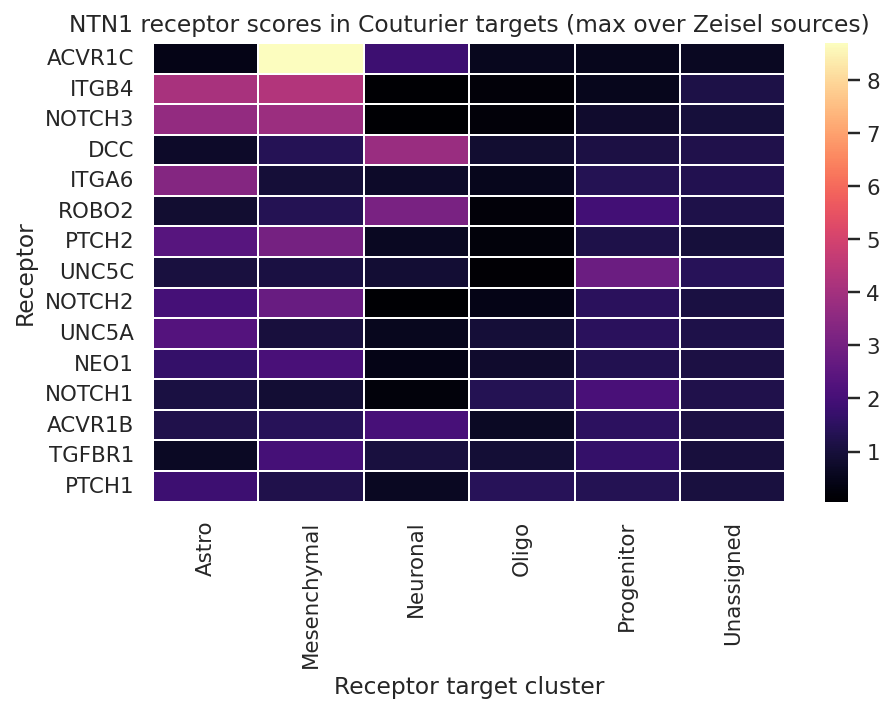

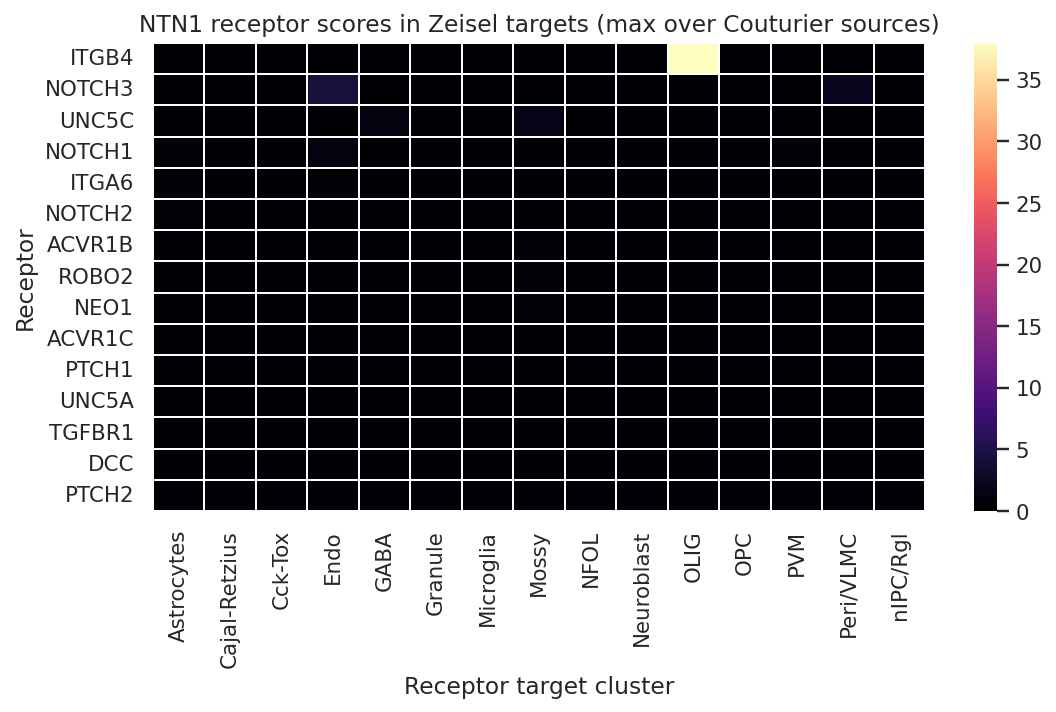

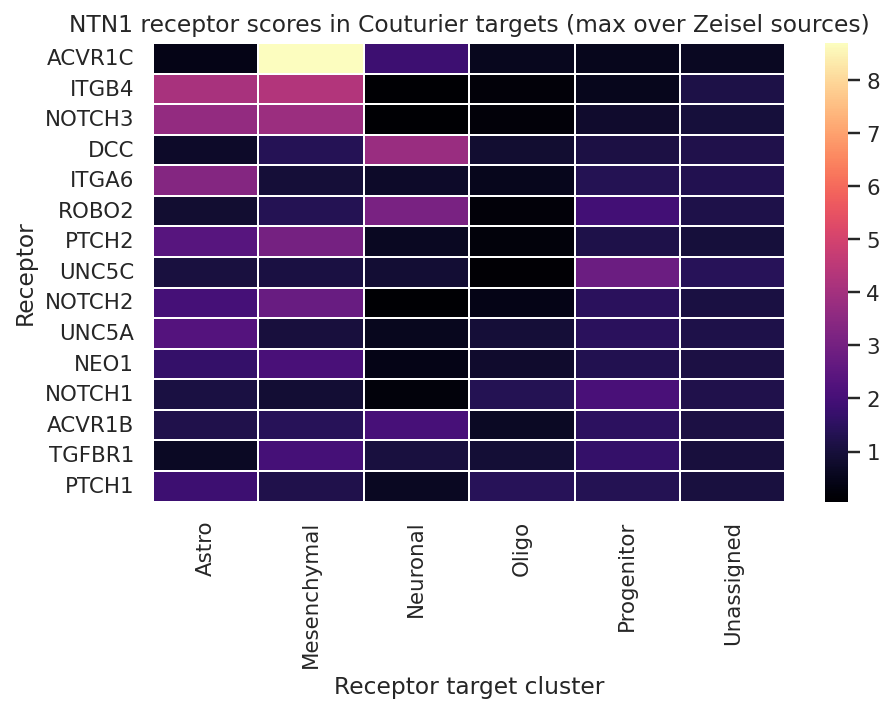

In [9]:
# NOTE: Visualize receptor-specific target cluster scores.
main_to_zeisel_receptor_mat, fig3a_path = CamelVicuna.plot_receptor_target_heatmap(
    long_scores,
    "Couturier2020_DevGBM -> ZeiselDentateGyrus_humanized",
    "NTN1 receptor scores in Zeisel targets (max over Couturier sources)",
    filename="fig3a_ntn1_receptor_scores_zeisel_targets.png",
    fig_dir=FIG_DIR,
    display_image=True,
)
zeisel_to_main_receptor_mat, fig3b_path = CamelVicuna.plot_receptor_target_heatmap(
    long_scores,
    "ZeiselDentateGyrus_humanized -> Couturier2020_DevGBM",
    "NTN1 receptor scores in Couturier targets (max over Zeisel sources)",
    filename="fig3b_ntn1_receptor_scores_couturier_targets.png",
    fig_dir=FIG_DIR,
    display_image=True,
)

CamelVicuna.save_table(main_to_zeisel_receptor_mat, TABLE_DIR / "ntn1_receptor_scores_zeisel_targets.csv")
CamelVicuna.save_table(zeisel_to_main_receptor_mat, TABLE_DIR / "ntn1_receptor_scores_couturier_targets.csv")
plt.show()


## 10. Plot top NTN1 ligand-receptor interactions

The readable bar plot wraps long labels and keeps the legend outside the plotting area.


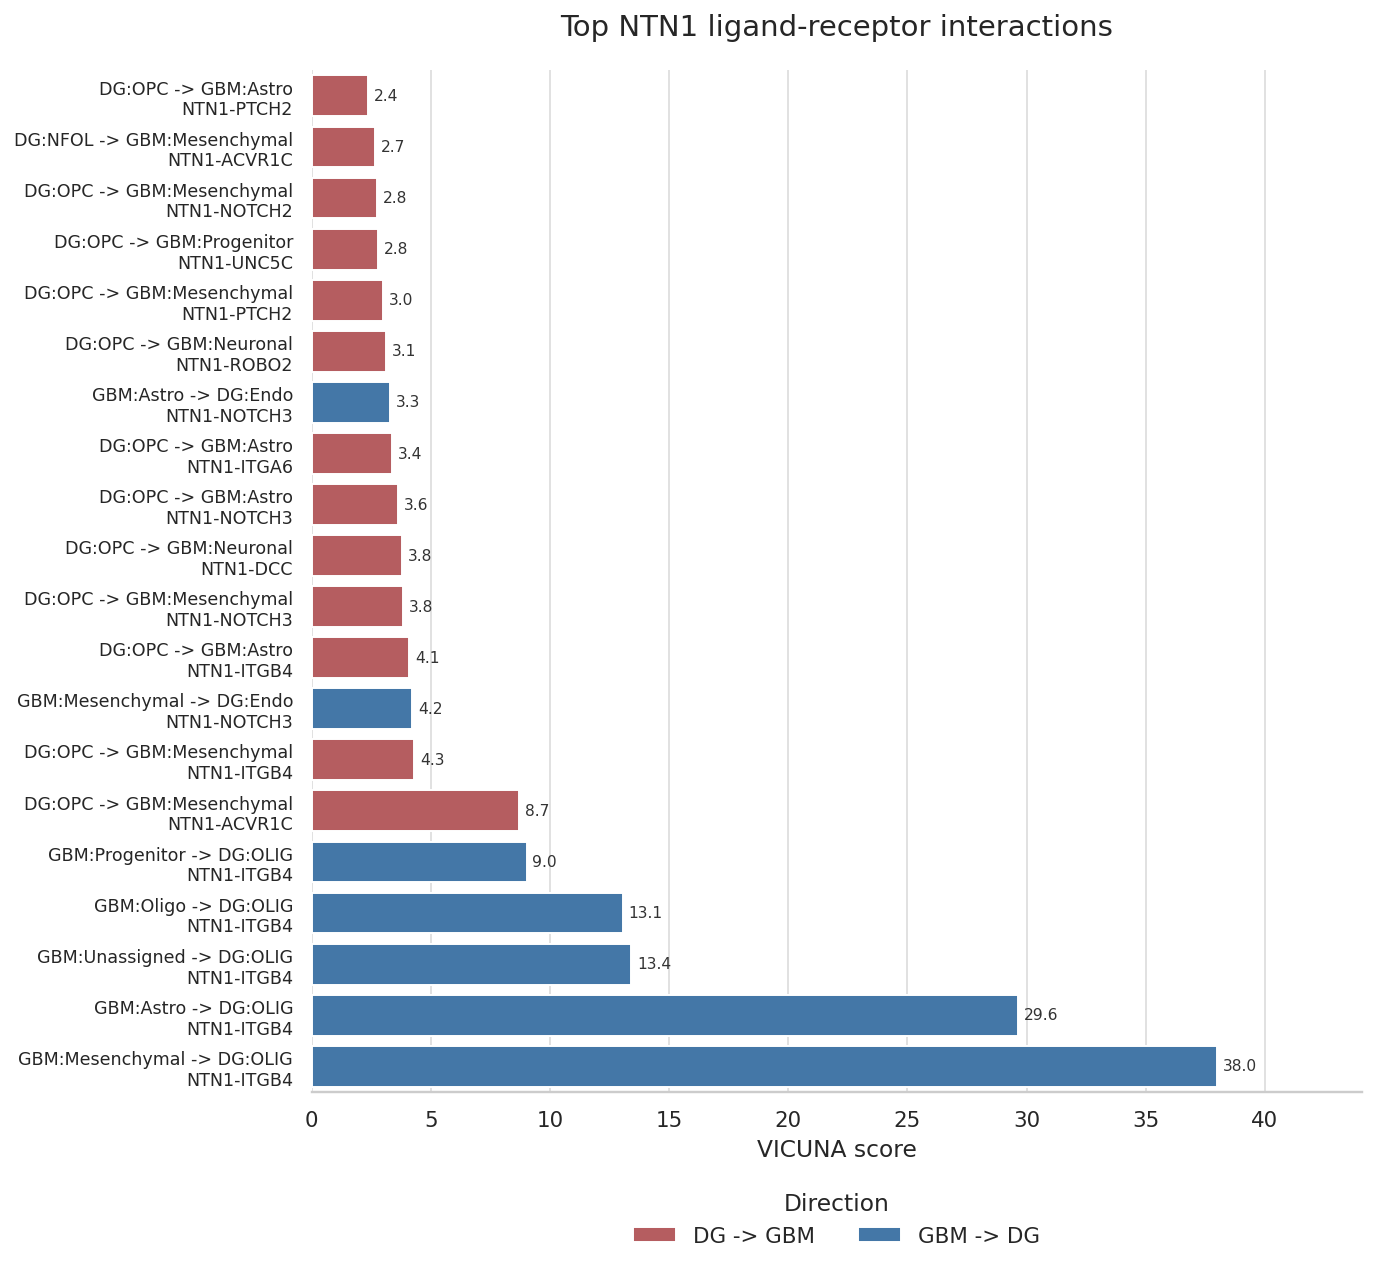

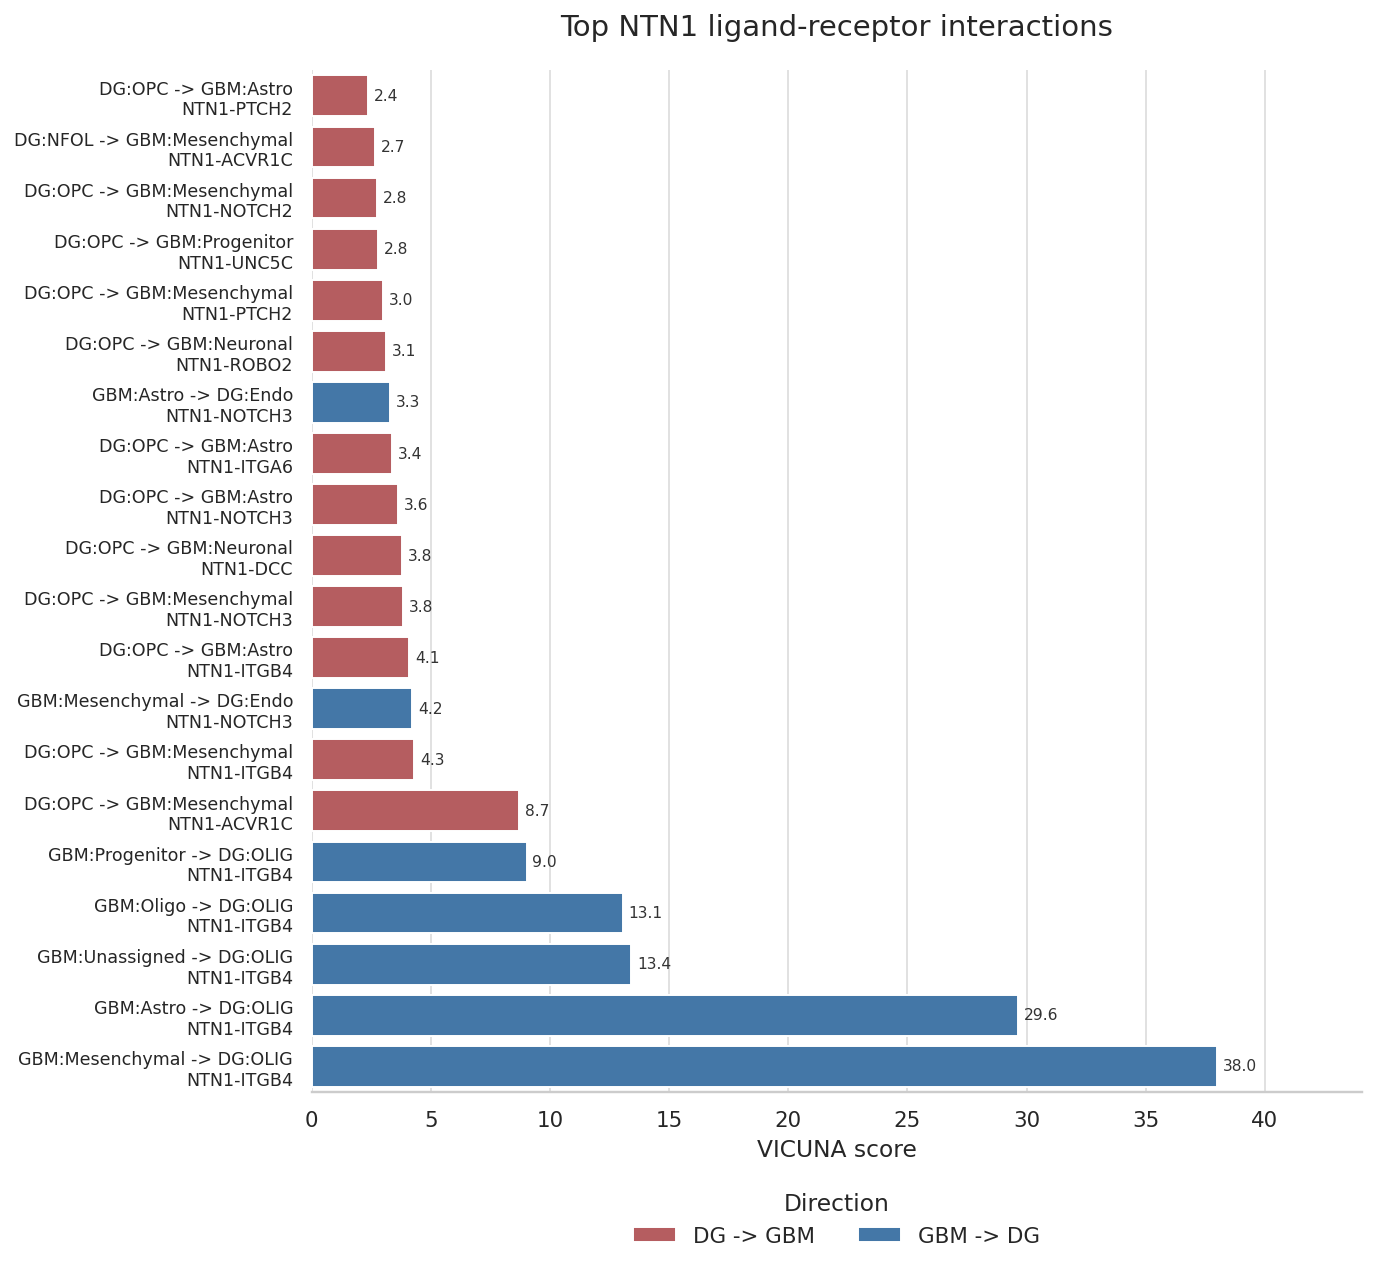

In [10]:
# NOTE: Visualize the top directional NTN1 interactions with readable wrapped labels.
top_plot, fig4_path = CamelVicuna.plot_top_directional_interactions(
    top_interactions,
    filename="fig4_top_ntn1_directional_interactions_readable.png",
    fig_dir=FIG_DIR,
    top_n=20,
    title="Top NTN1 ligand-receptor interactions",
    display_image=True,
)
CamelVicuna.save_table(top_plot, TABLE_DIR / "ntn1_top20_directional_scores_for_plot.csv")
plt.show()


## 11. Chord-style cluster communication plot

This static chord-style summary shows the strongest cluster-pair communication paths while keeping labels and legend away from the circle.


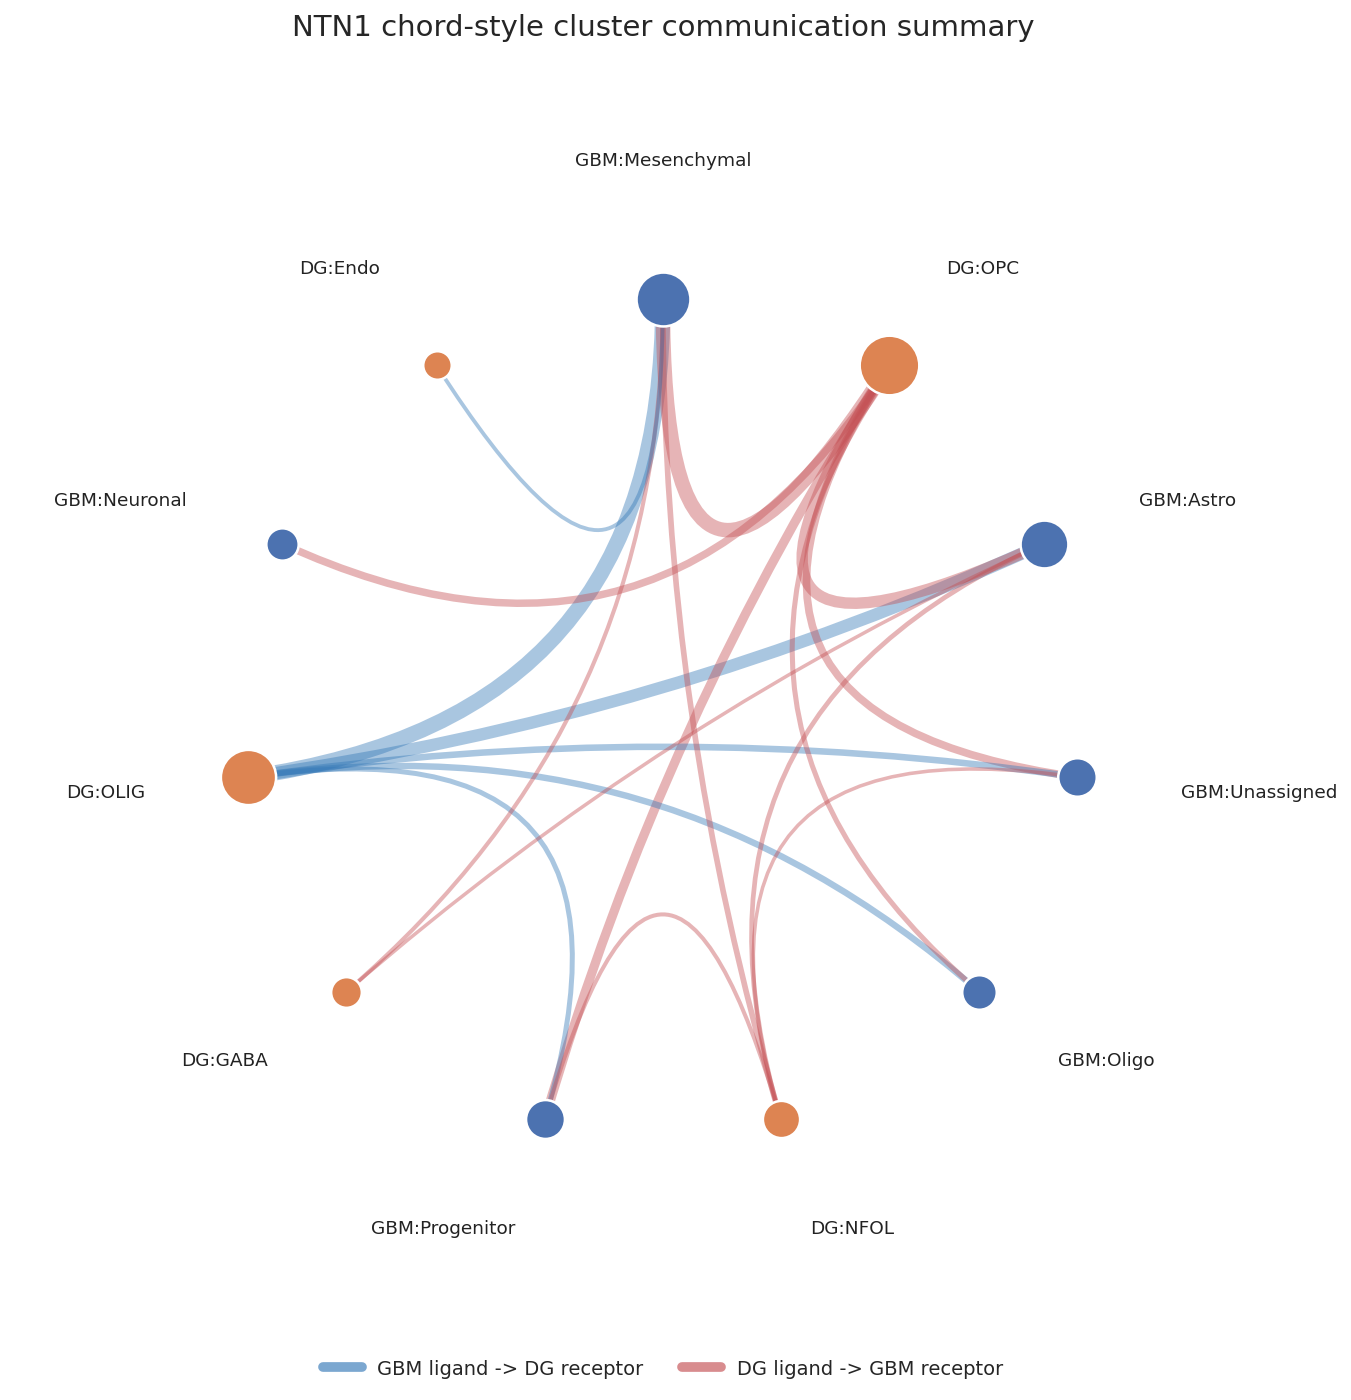

,direction,direction_short,source_node,target_node,score
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Mesenchymal,DG:OLIG,38.356154
13,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Mesenchymal,35.835365
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Astro,DG:OLIG,29.938549
12,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Astro,27.216096
16,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Progenitor,20.990887
17,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Unassigned,16.663185
14,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:OPC,GBM:Neuronal,16.112459
5,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Unassigned,DG:OLIG,13.540250
3,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,GBM -> DG,GBM:Oligo,DG:OLIG,13.181904
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,DG -> GBM,DG:NFOL,GBM:Mesenchymal,11.018728


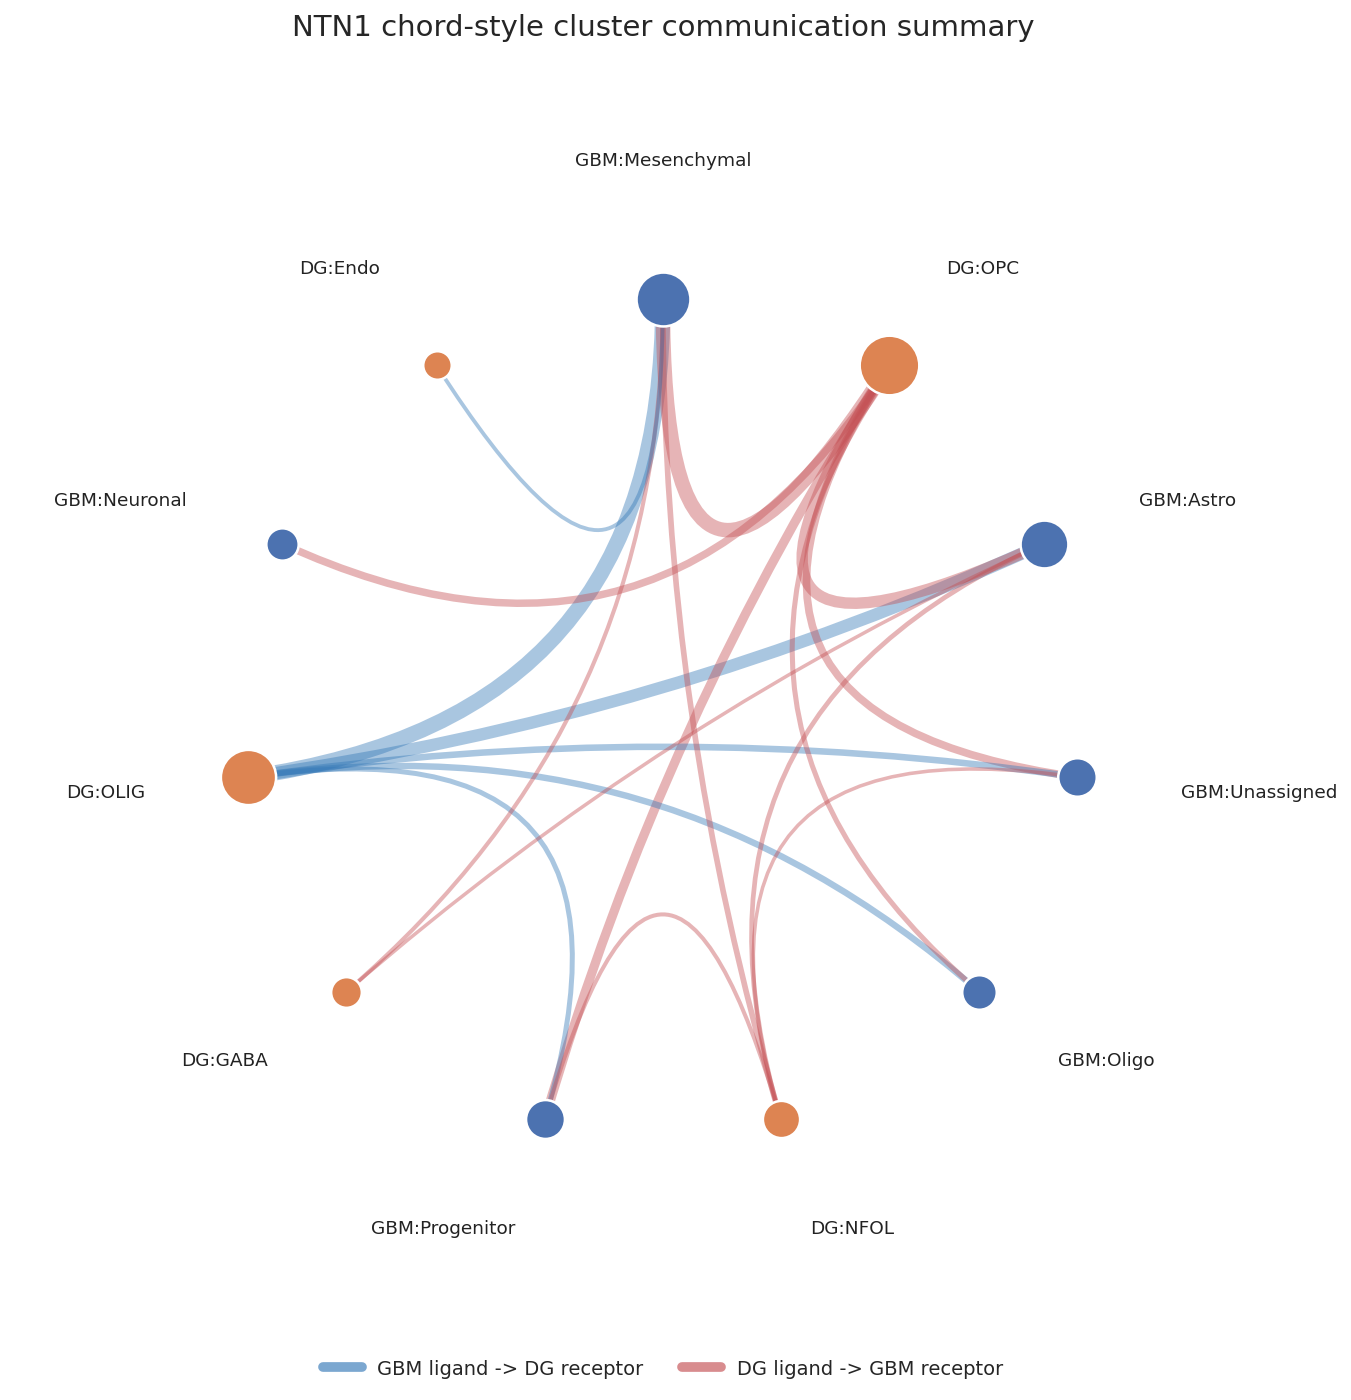

In [11]:
# NOTE: Draw the chord-style cluster communication summary.
chord_edges, chord_path = CamelVicuna.draw_chord_plot(
    cluster_pair_summary,
    filename="fig5_ntn1_chord_cluster_communication_readable.png",
    fig_dir=FIG_DIR,
    top_n=18,
    title="NTN1 chord-style cluster communication summary",
    display_image=True,
)
display(chord_edges)
CamelVicuna.save_table(chord_edges, TABLE_DIR / "ntn1_chord_edges_top_cluster_pairs_readable.csv")
plt.show()


## 12. Sankey/alluvial plot for top paths

The Sankey-style plot follows top individual paths from source cluster to NTN1 receptor to target cluster.


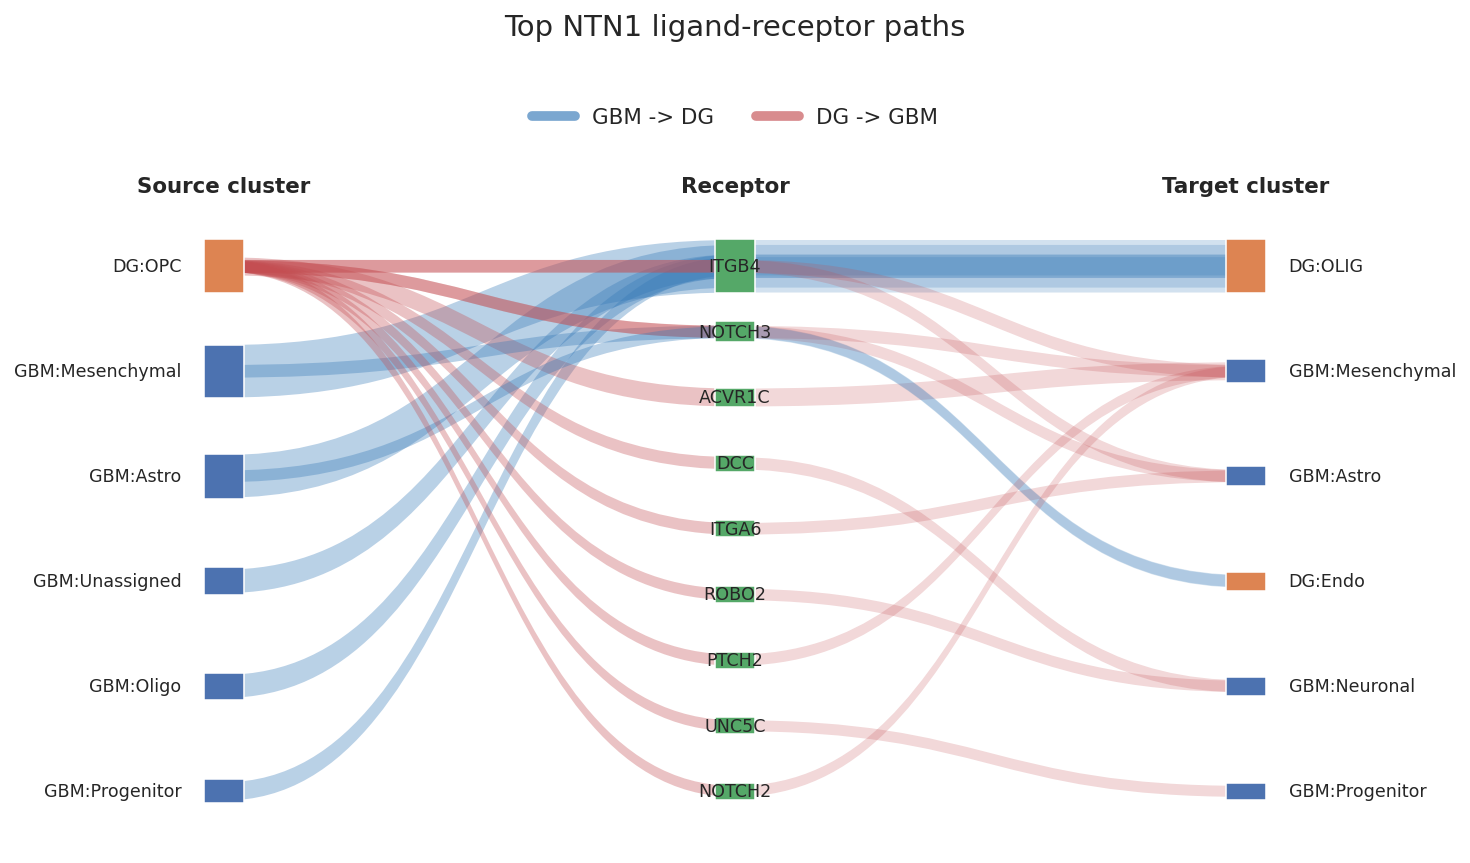

,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score,source_node,target_node,receptor_node,direction_short
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537,GBM:Mesenchymal,DG:OLIG,ITGB4,GBM -> DG
1,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023,GBM:Astro,DG:OLIG,ITGB4,GBM -> DG
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593,GBM:Unassigned,DG:OLIG,ITGB4,GBM -> DG
3,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785,GBM:Oligo,DG:OLIG,ITGB4,GBM -> DG
4,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840,GBM:Progenitor,DG:OLIG,ITGB4,GBM -> DG
5,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030,DG:OPC,GBM:Mesenchymal,ACVR1C,DG -> GBM
6,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583,DG:OPC,GBM:Mesenchymal,ITGB4,DG -> GBM
7,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401,GBM:Mesenchymal,DG:Endo,NOTCH3,GBM -> DG
8,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730,DG:OPC,GBM:Astro,ITGB4,DG -> GBM
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139,DG:OPC,GBM:Mesenchymal,NOTCH3,DG -> GBM


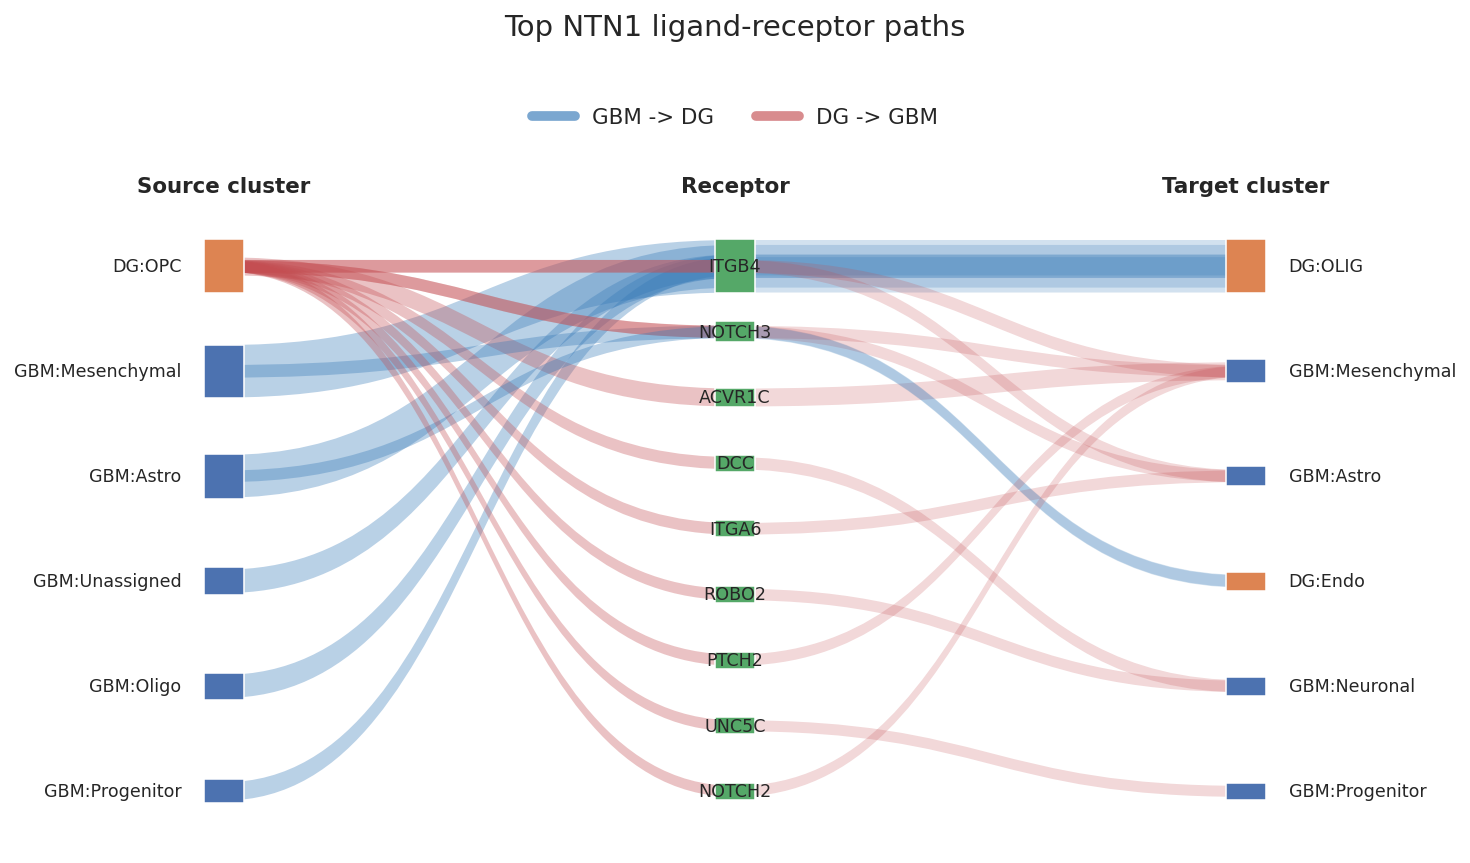

In [12]:
# NOTE: Draw the top individual NTN1 paths as source cluster -> receptor -> target cluster.
sankey_flows, sankey_path = CamelVicuna.draw_sankey_alluvial(
    top_interactions,
    filename="fig6_ntn1_sankey_top_paths_readable.png",
    fig_dir=FIG_DIR,
    top_n=18,
    title="Top NTN1 ligand-receptor paths",
    display_image=True,
)
display(sankey_flows)
CamelVicuna.save_table(sankey_flows, TABLE_DIR / "ntn1_sankey_top_flows_readable.csv")
plt.show()


## 13. Review key results and generated files

The final cell lists the most important tables and figures created by the tutorial.


In [13]:
# NOTE: Display final result tables and list saved tutorial artifacts.
print("Top 20 interactions")
display(top_interactions.head(20))

print("Available NTN1 receptor pairs")
display(ntn1_pairs)

print("Cluster-pair summary")
display(cluster_pair_summary.head(30))

print("\nTables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", path)

print("\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" -", path)


Top 20 interactions


,direction,source_dataset,target_dataset,source_cluster,target_cluster,pair,ligand,receptor,score
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,OLIG,NTN1-ITGB4,NTN1,ITGB4,37.977537
1,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Astro,OLIG,NTN1-ITGB4,NTN1,ITGB4,29.643023
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Unassigned,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.406593
3,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Oligo,OLIG,NTN1-ITGB4,NTN1,ITGB4,13.051785
4,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Progenitor,OLIG,NTN1-ITGB4,NTN1,ITGB4,9.019840
5,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ACVR1C,NTN1,ACVR1C,8.698030
6,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-ITGB4,NTN1,ITGB4,4.295583
7,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Couturier2020_DevGBM,ZeiselDentateGyrus_humanized,Mesenchymal,Endo,NTN1-NOTCH3,NTN1,NOTCH3,4.228401
8,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Astro,NTN1-ITGB4,NTN1,ITGB4,4.090730
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,ZeiselDentateGyrus_humanized,Couturier2020_DevGBM,OPC,Mesenchymal,NTN1-NOTCH3,NTN1,NOTCH3,3.827139


Available NTN1 receptor pairs


,PPI,ligand_symbol,receptor_symbol,receptor_in_couturier,ligand_in_couturier,receptor_in_zeisel_humanized,ligand_in_zeisel_humanized
NTN1-DCC,NTN1_DCC,NTN1,DCC,True,True,True,True
NTN1-UNC5C,NTN1_UNC5C,NTN1,UNC5C,True,True,True,True
NTN1-NEO1,NTN1_NEO1,NTN1,NEO1,True,True,True,True
NTN1-ITGB4,NTN1_ITGB4,NTN1,ITGB4,True,True,True,True
NTN1-ITGA6,NTN1_ITGA6,NTN1,ITGA6,True,True,True,True
NTN1-ACVR1B,NTN1_ACVR1B,NTN1,ACVR1B,True,True,True,True
NTN1-TGFBR1,NTN1_TGFBR1,NTN1,TGFBR1,True,True,True,True
NTN1-NOTCH1,NTN1_NOTCH1,NTN1,NOTCH1,True,True,True,True
NTN1-NOTCH2,NTN1_NOTCH2,NTN1,NOTCH2,True,True,True,True
NTN1-PTCH1,NTN1_PTCH1,NTN1,PTCH1,True,True,True,True


Cluster-pair summary


,direction,source_cluster,target_cluster,score
0,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Mesenchymal,OLIG,38.356154
1,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Mesenchymal,35.835365
2,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Astro,OLIG,29.938549
3,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Astro,27.216096
4,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Progenitor,20.990887
5,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Unassigned,16.663185
6,ZeiselDentateGyrus_humanized -> Couturier2020_...,OPC,Neuronal,16.112459
7,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Unassigned,OLIG,13.540250
8,Couturier2020_DevGBM -> ZeiselDentateGyrus_hum...,Oligo,OLIG,13.181904
9,ZeiselDentateGyrus_humanized -> Couturier2020_...,NFOL,Mesenchymal,11.018728



Tables:
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/cluster_counts.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/couturier_escore_genes_by_cluster.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/dataset_summary.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_all_directional_scores_long.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_chord_edges_top_cluster_pairs_readable.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updated_20260610/outputs/ntn1_couturier_zeisel_pypi047b1_tutorial/tables/ntn1_cluster_pair_score_summary.csv
 - /mnt/e/Loal_Temp/Vicuna_Example/scCAMEL_VICUNA_updat